# Notebook 03: Multi-Class Classification Modelling
## Wearable-Enhanced Insurance Underwriting — NHANES 2003-2004

**Author:** Lubaba Hassan | 22097014D | PolyU Data Science and Analytics

This notebook trains and evaluates **four classifiers** across **three feature scenarios**
to answer the research questions:

- **RQ1:** Do Wang (2021) patterns generalise to three-class classification on NHANES?
- **RQ2:** What is the incremental value of wearable features? (Scenario A vs B)
- **RQ3:** Which classifier/scenario combination best balances performance, interpretability, and fairness?

**Classifiers:** Logistic Regression, Decision Tree, Random Forest, XGBoost

**Scenarios:**
- A: Traditional clinical features only (13 features, 3,388 participants)
- B: Traditional + Wearable features (20 features, 1,887 participants)
- C: Wearable features only (7 features, 1,887 participants)

**Evaluation Metrics:** Macro AUC-ROC (OVR), Macro F1, Weighted F1, Brier Score, Per-class metrics

**Methodology:**
- Stratified 80/20 train-test split
- Stratified 5-fold cross-validation on training set for model selection
- Class-weighted models to handle Intermediate class imbalance
- Hyperparameter tuning via GridSearchCV

## 1. Imports and Configuration

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, brier_score_loss, make_scorer,
    accuracy_score
)

DATA_PATH = '../data/processed/'
FIGURES_PATH = '../reports/figures/'

RANDOM_STATE = 42
N_FOLDS = 5
TEST_SIZE = 0.2

LABEL_COL = 'risk_class'
LABEL_NAMES = {0: 'Low', 1: 'Intermediate', 2: 'High'}
CLASS_ORDER = ['Low', 'Intermediate', 'High']

print('All imports successful.')
print(f'Random state: {RANDOM_STATE}')
print(f'CV folds: {N_FOLDS}')
print(f'Test size: {TEST_SIZE}')

All imports successful.
Random state: 42
CV folds: 5
Test size: 0.2


## 2. Load Data and Define Feature Sets

In [8]:
scenario_a = pd.read_csv(DATA_PATH + 'scenario_a.csv')
scenario_b = pd.read_csv(DATA_PATH + 'scenario_b.csv')
scenario_c = pd.read_csv(DATA_PATH + 'scenario_c.csv')

TRADITIONAL_FEATURES = [
    'age', 'male', 'bmi', 'waist_cm',
    'systolic_bp', 'diastolic_bp',
    'total_cholesterol', 'hdl_cholesterol',
    'ever_smoker', 'self_rated_health',
    'daily_activity_level', 'high_chol_told',
    'bp_hypertension_measured'
]
WEARABLE_FEATURES = [
    'total_met_hours', 'mean_met', 'total_activities',
    'moderate_count', 'vigorous_count', 'vigorous_ratio',
    'activity_category'
]

SCENARIOS = {
    'A': {'data': scenario_a, 'features': TRADITIONAL_FEATURES,
          'name': 'Traditional Only'},
    'B': {'data': scenario_b, 'features': TRADITIONAL_FEATURES + WEARABLE_FEATURES,
          'name': 'Traditional + Wearable'},
    'C': {'data': scenario_c, 'features': WEARABLE_FEATURES,
          'name': 'Wearable Only'},
}

for key, scen in SCENARIOS.items():
    print(f'Scenario {key} ({scen["name"]}): {scen["data"].shape[0]:,} rows, '
          f'{len(scen["features"])} features')

Scenario A (Traditional Only): 3,388 rows, 13 features
Scenario B (Traditional + Wearable): 1,887 rows, 20 features
Scenario C (Wearable Only): 1,887 rows, 7 features


## 3. Define Classifiers and Hyperparameter Grids

In [9]:
# Classifier definitions with hyperparameter grids for tuning
# All classifiers use class_weight='balanced' where supported

CLASSIFIERS = {
    'Logistic Regression': {
        'model': LogisticRegression(
            max_iter=2000, class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'solver': ['lbfgs']
        },
        'scale': True
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(
            class_weight='balanced', random_state=RANDOM_STATE
        ),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [5, 10, 20],
            'min_samples_leaf': [2, 5, 10]
        },
        'scale': False
    },
    'Random Forest': {
        'model': RandomForestClassifier(
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
        ),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [5, 10],
            'min_samples_leaf': [2, 5]
        },
        'scale': False
    },
    'XGBoost': {
        'model': XGBClassifier(
            objective='multi:softprob', num_class=3,
            eval_metric='mlogloss', use_label_encoder=False,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.05, 0.1, 0.2],
            'subsample': [0.8, 1.0]
        },
        'scale': False
    }
}

print(f'Classifiers defined: {len(CLASSIFIERS)}')
for name in CLASSIFIERS:
    n_combos = 1
    for v in CLASSIFIERS[name]['params'].values():
        n_combos *= len(v)
    print(f'  {name}: {n_combos} hyperparameter combinations')

Classifiers defined: 4
  Logistic Regression: 4 hyperparameter combinations
  Decision Tree: 45 hyperparameter combinations
  Random Forest: 32 hyperparameter combinations
  XGBoost: 36 hyperparameter combinations


## 4. Training and Evaluation Pipeline

In [10]:
def compute_multiclass_brier(y_true, y_prob, n_classes=3):
    """Compute multi-class Brier score (lower is better)."""
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    return np.mean(np.sum((y_prob - y_bin) ** 2, axis=1))


def train_and_evaluate(scenario_key, clf_name, clf_config):
    """
    Full pipeline: split, scale, tune, train, evaluate.
    Returns dict of results.
    """
    scen = SCENARIOS[scenario_key]
    df = scen['data']
    features = scen['features']
    
    X = df[features].values
    y = df[LABEL_COL].values.astype(int)
    
    # Stratified train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    
    # Scale if needed (Logistic Regression)
    scaler = None
    if clf_config['scale']:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
    # Compute sample weights for XGBoost (doesn't support class_weight)
    sample_weights = None
    if clf_name == 'XGBoost':
        from sklearn.utils.class_weight import compute_sample_weight
        sample_weights = compute_sample_weight('balanced', y_train)
    
    # GridSearchCV with stratified k-fold
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scorer = make_scorer(f1_score, average='macro')
    
    grid = GridSearchCV(
        clf_config['model'], clf_config['params'],
        cv=cv, scoring=scorer, n_jobs=-1, refit=True
    )
    
    start_time = time.time()
    if sample_weights is not None:
        grid.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        grid.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Probability predictions for AUC and Brier
    if hasattr(best_model, 'predict_proba'):
        y_prob = best_model.predict_proba(X_test)
    else:
        y_prob = None
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    
    if y_prob is not None:
        y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
        macro_auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
        brier = compute_multiclass_brier(y_test, y_prob)
    else:
        macro_auc = np.nan
        brier = np.nan
    
    # Per-class F1
    per_class_f1 = f1_score(y_test, y_pred, average=None)
    
    # CV score
    cv_score = grid.best_score_
    
    return {
        'scenario': scenario_key,
        'classifier': clf_name,
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'macro_auc': macro_auc,
        'brier_score': brier,
        'cv_macro_f1': cv_score,
        'f1_low': per_class_f1[0],
        'f1_intermediate': per_class_f1[1],
        'f1_high': per_class_f1[2],
        'train_time': train_time,
        'best_params': grid.best_params_,
        'model': best_model,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'X_test': X_test,
        'scaler': scaler
    }


print('Training pipeline defined.')

Training pipeline defined.


## 5. Train All Models

In [11]:
# Train all classifiers across all scenarios
all_results = []
results_dict = {}  # For easy lookup: results_dict['A']['Random Forest']

total_combos = len(SCENARIOS) * len(CLASSIFIERS)
combo_idx = 0

for scen_key in ['A', 'B', 'C']:
    results_dict[scen_key] = {}
    print(f'\n{"="*60}')
    print(f'SCENARIO {scen_key}: {SCENARIOS[scen_key]["name"]}')
    print(f'{"="*60}')
    
    for clf_name, clf_config in CLASSIFIERS.items():
        combo_idx += 1
        print(f'\n  [{combo_idx}/{total_combos}] Training {clf_name}...')
        
        result = train_and_evaluate(scen_key, clf_name, clf_config)
        all_results.append(result)
        results_dict[scen_key][clf_name] = result
        
        print(f'    CV Macro-F1:   {result["cv_macro_f1"]:.4f}')
        print(f'    Test Macro-F1: {result["macro_f1"]:.4f}')
        print(f'    Test AUC:      {result["macro_auc"]:.4f}')
        print(f'    Brier Score:   {result["brier_score"]:.4f}')
        print(f'    Time:          {result["train_time"]:.1f}s')
        print(f'    Best params:   {result["best_params"]}')

print(f'\n{"="*60}')
print(f'ALL {total_combos} MODELS TRAINED SUCCESSFULLY')
print(f'{"="*60}')


SCENARIO A: Traditional Only

  [1/12] Training Logistic Regression...
    CV Macro-F1:   0.7510
    Test Macro-F1: 0.7368
    Test AUC:      0.9036
    Brier Score:   0.3349
    Time:          7.0s
    Best params:   {'C': 1, 'solver': 'lbfgs'}

  [2/12] Training Decision Tree...
    CV Macro-F1:   0.8568
    Test Macro-F1: 0.8058
    Test AUC:      0.9202
    Brier Score:   0.2703
    Time:          1.0s
    Best params:   {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 20}

  [3/12] Training Random Forest...
    CV Macro-F1:   0.8763
    Test Macro-F1: 0.8515
    Test AUC:      0.9647
    Brier Score:   0.2008
    Time:          17.8s
    Best params:   {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}

  [4/12] Training XGBoost...
    CV Macro-F1:   0.8861
    Test Macro-F1: 0.8775
    Test AUC:      0.9698
    Brier Score:   0.1694
    Time:          14.8s
    Best params:   {'learning_rate': 0.05, 'max_depth': 7, 'n_estimato

## 6. Results Summary Table

In [12]:
# Build results dataframe
results_df = pd.DataFrame([{
    'Scenario': r['scenario'],
    'Classifier': r['classifier'],
    'CV Macro-F1': r['cv_macro_f1'],
    'Test Accuracy': r['accuracy'],
    'Test Macro-F1': r['macro_f1'],
    'Test Weighted-F1': r['weighted_f1'],
    'Test Macro-AUC': r['macro_auc'],
    'Brier Score': r['brier_score'],
    'F1 Low': r['f1_low'],
    'F1 Intermediate': r['f1_intermediate'],
    'F1 High': r['f1_high'],
    'Train Time (s)': r['train_time']
} for r in all_results])

print('FULL RESULTS TABLE')
print('=' * 100)
display_cols = ['Scenario', 'Classifier', 'Test Macro-F1', 'Test Macro-AUC',
                'Brier Score', 'F1 Low', 'F1 Intermediate', 'F1 High']
print(results_df[display_cols].to_string(index=False, float_format='{:.4f}'.format))

FULL RESULTS TABLE
Scenario          Classifier  Test Macro-F1  Test Macro-AUC  Brier Score  F1 Low  F1 Intermediate  F1 High
       A Logistic Regression         0.7368          0.9036       0.3349  0.8460           0.5732   0.7913
       A       Decision Tree         0.8058          0.9202       0.2703  0.9018           0.6908   0.8247
       A       Random Forest         0.8515          0.9647       0.2008  0.9247           0.7676   0.8623
       A             XGBoost         0.8775          0.9698       0.1694  0.9305           0.8166   0.8854
       B Logistic Regression         0.7788          0.9334       0.2759  0.8902           0.6108   0.8352
       B       Decision Tree         0.8398          0.9424       0.2016  0.9429           0.7394   0.8372
       B       Random Forest         0.8619          0.9680       0.2128  0.9545           0.7482   0.8830
       B             XGBoost         0.9004          0.9776       0.1284  0.9883           0.8267   0.8864
       C Logistic 

In [13]:
# Pivot table: Macro-F1 by Scenario and Classifier
print('\nMACRO-F1 COMPARISON (higher is better)')
print('=' * 60)
pivot_f1 = results_df.pivot(index='Classifier', columns='Scenario', values='Test Macro-F1')
pivot_f1 = pivot_f1[['A', 'B', 'C']]
pivot_f1['B-A Diff'] = pivot_f1['B'] - pivot_f1['A']
print(pivot_f1.round(4).to_string())

print('\nMACRO-AUC COMPARISON (higher is better)')
print('=' * 60)
pivot_auc = results_df.pivot(index='Classifier', columns='Scenario', values='Test Macro-AUC')
pivot_auc = pivot_auc[['A', 'B', 'C']]
pivot_auc['B-A Diff'] = pivot_auc['B'] - pivot_auc['A']
print(pivot_auc.round(4).to_string())

print('\nBRIER SCORE COMPARISON (lower is better)')
print('=' * 60)
pivot_brier = results_df.pivot(index='Classifier', columns='Scenario', values='Brier Score')
pivot_brier = pivot_brier[['A', 'B', 'C']]
pivot_brier['B-A Diff'] = pivot_brier['B'] - pivot_brier['A']
print(pivot_brier.round(4).to_string())


MACRO-F1 COMPARISON (higher is better)
Scenario                  A       B       C  B-A Diff
Classifier                                           
Decision Tree        0.8058  0.8398  0.3668    0.0341
Logistic Regression  0.7368  0.7788  0.3907    0.0419
Random Forest        0.8515  0.8619  0.3725    0.0104
XGBoost              0.8775  0.9004  0.3852    0.0230

MACRO-AUC COMPARISON (higher is better)
Scenario                  A       B       C  B-A Diff
Classifier                                           
Decision Tree        0.9202  0.9424  0.5272    0.0222
Logistic Regression  0.9036  0.9334  0.5629    0.0299
Random Forest        0.9647  0.9680  0.5409    0.0033
XGBoost              0.9698  0.9776  0.5449    0.0078

BRIER SCORE COMPARISON (lower is better)
Scenario                  A       B       C  B-A Diff
Classifier                                           
Decision Tree        0.2703  0.2016  0.6792   -0.0687
Logistic Regression  0.3349  0.2759  0.6466   -0.0590
Random Forest

## 7. Performance Visualizations

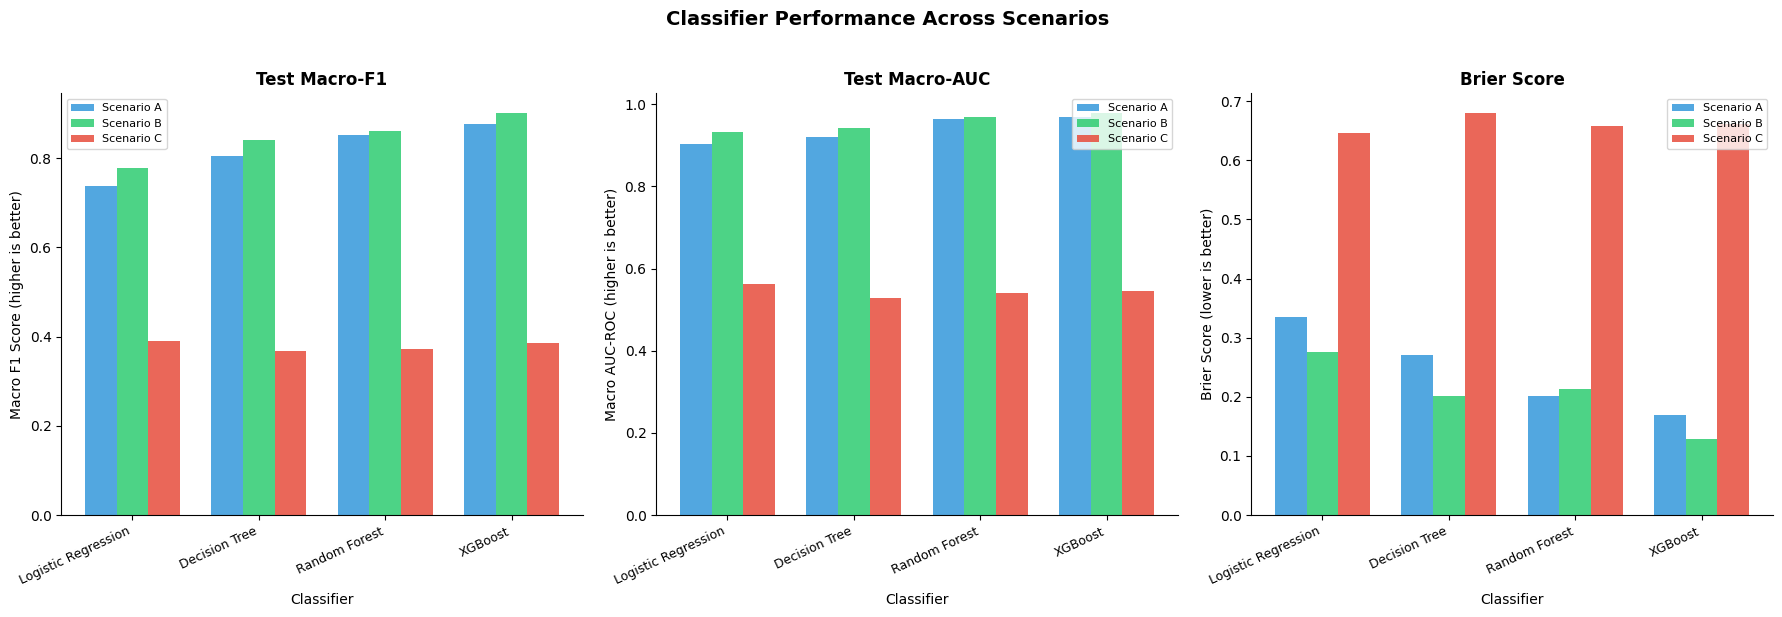

Figure saved.


In [14]:
# Grouped bar chart: Macro-F1 by classifier and scenario
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    ('Test Macro-F1', 'Macro F1 Score (higher is better)'),
    ('Test Macro-AUC', 'Macro AUC-ROC (higher is better)'),
    ('Brier Score', 'Brier Score (lower is better)')
]

scenario_colors = {'A': '#3498db', 'B': '#2ecc71', 'C': '#e74c3c'}
clf_names = list(CLASSIFIERS.keys())

for ax, (metric, ylabel) in zip(axes, metrics):
    x = np.arange(len(clf_names))
    width = 0.25
    for i, scen in enumerate(['A', 'B', 'C']):
        vals = [results_df[(results_df['Scenario'] == scen) & 
                           (results_df['Classifier'] == clf)][metric].values[0]
                for clf in clf_names]
        bars = ax.bar(x + i*width, vals, width, label=f'Scenario {scen}',
                      color=scenario_colors[scen], alpha=0.85)
    ax.set_xlabel('Classifier')
    ax.set_ylabel(ylabel)
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(clf_names, rotation=25, ha='right', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Classifier Performance Across Scenarios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'model_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

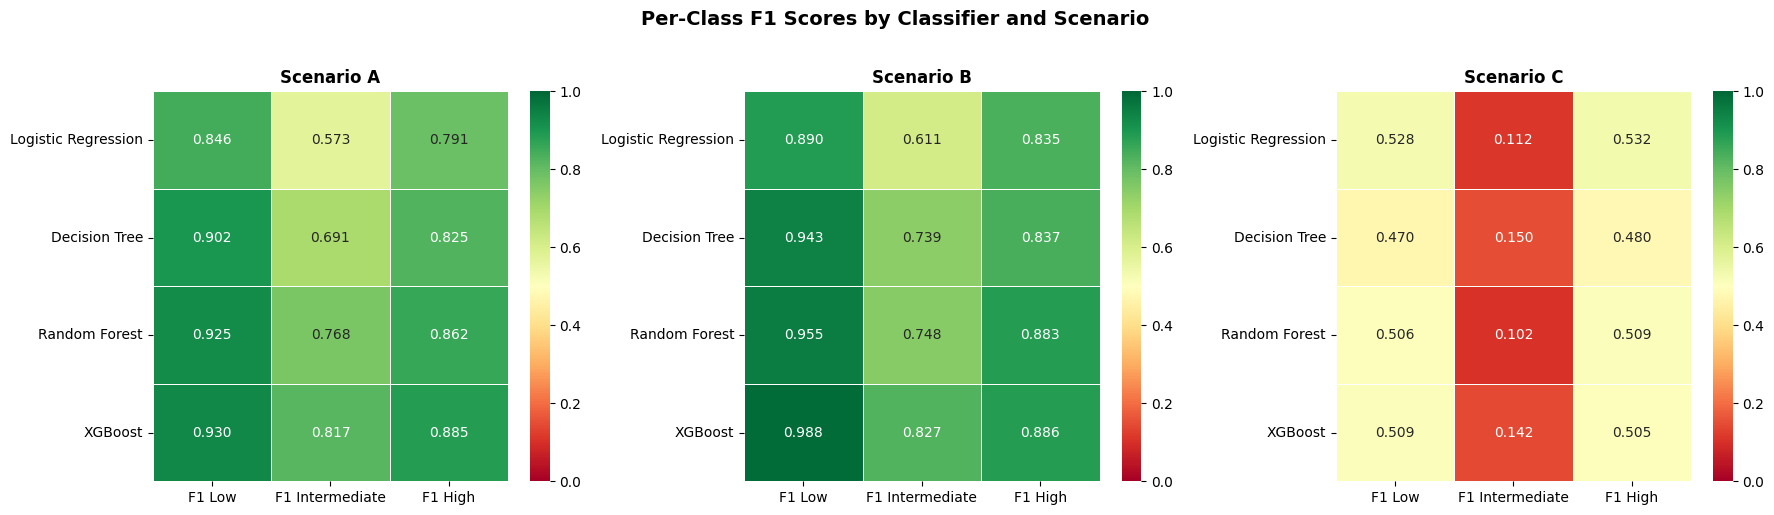

Figure saved.


In [15]:
# Per-class F1 heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, scen in zip(axes, ['A', 'B', 'C']):
    scen_df = results_df[results_df['Scenario'] == scen]
    heatmap_data = scen_df.set_index('Classifier')[['F1 Low', 'F1 Intermediate', 'F1 High']]
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(f'Scenario {scen}', fontweight='bold')
    ax.set_ylabel('')

plt.suptitle('Per-Class F1 Scores by Classifier and Scenario',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'model_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 8. Confusion Matrices

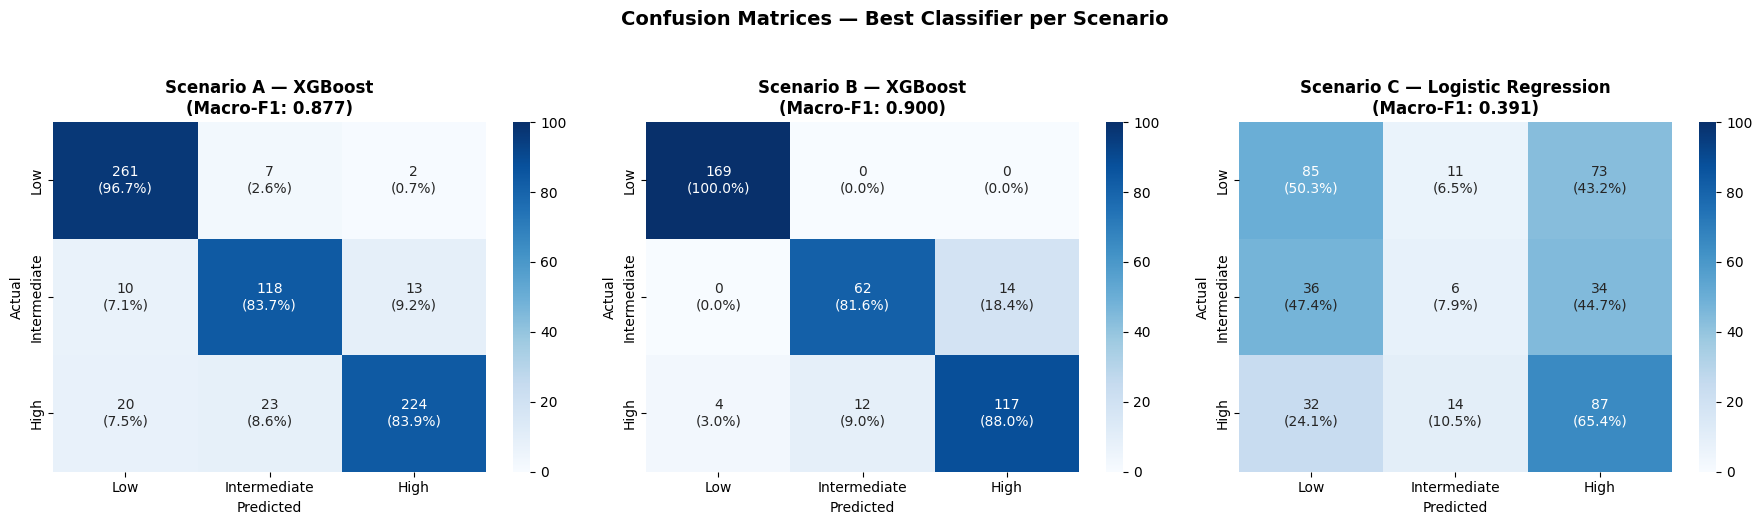

Figure saved.


In [16]:
# Confusion matrices for best model per scenario
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, scen in zip(axes, ['A', 'B', 'C']):
    # Find best classifier by Macro-F1 for this scenario
    scen_results = results_df[results_df['Scenario'] == scen]
    best_row = scen_results.loc[scen_results['Test Macro-F1'].idxmax()]
    best_clf = best_row['Classifier']
    result = results_dict[scen][best_clf]
    
    cm = confusion_matrix(result['y_test'], result['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    
    # Create annotation with count and percentage
    annot = np.array([[f'{count}\n({pct:.1f}%)' 
                       for count, pct in zip(row_c, row_p)] 
                      for row_c, row_p in zip(cm, cm_pct)])
    
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                ax=ax, vmin=0, vmax=100)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Scenario {scen} — {best_clf}\n(Macro-F1: {best_row["Test Macro-F1"]:.3f})',
                 fontweight='bold')

plt.suptitle('Confusion Matrices — Best Classifier per Scenario',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'model_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 9. Scenario A vs B: Incremental Wearable Value (RQ2)

In [17]:
# Direct comparison of A vs B for each classifier
# Note: B uses a subset of A's participants, so we also train A on B's subset for fair comparison

print('SCENARIO A vs B: INCREMENTAL VALUE OF WEARABLE FEATURES (RQ2)')
print('=' * 70)
print(f'\nNote: Scenario B uses {len(scenario_b):,} participants (subset with wearable data).')
print(f'Scenario A uses {len(scenario_a):,} participants (full dataset).')
print(f'For fair comparison, the B-A Diff column compares on different sample sizes.')
print(f'A like-for-like comparison would train A on the B subset only.\n')

print(f'{"Classifier":25s} {"A Macro-F1":>12s} {"B Macro-F1":>12s} {"Diff":>8s} {"A AUC":>8s} {"B AUC":>8s} {"Diff":>8s}')
print('-' * 85)
for clf_name in CLASSIFIERS:
    a_res = results_dict['A'][clf_name]
    b_res = results_dict['B'][clf_name]
    f1_diff = b_res['macro_f1'] - a_res['macro_f1']
    auc_diff = b_res['macro_auc'] - a_res['macro_auc']
    print(f'{clf_name:25s} {a_res["macro_f1"]:>12.4f} {b_res["macro_f1"]:>12.4f} {f1_diff:>+8.4f} '
          f'{a_res["macro_auc"]:>8.4f} {b_res["macro_auc"]:>8.4f} {auc_diff:>+8.4f}')

SCENARIO A vs B: INCREMENTAL VALUE OF WEARABLE FEATURES (RQ2)

Note: Scenario B uses 1,887 participants (subset with wearable data).
Scenario A uses 3,388 participants (full dataset).
For fair comparison, the B-A Diff column compares on different sample sizes.
A like-for-like comparison would train A on the B subset only.

Classifier                  A Macro-F1   B Macro-F1     Diff    A AUC    B AUC     Diff
-------------------------------------------------------------------------------------
Logistic Regression             0.7368       0.7788  +0.0419   0.9036   0.9334  +0.0299
Decision Tree                   0.8058       0.8398  +0.0341   0.9202   0.9424  +0.0222
Random Forest                   0.8515       0.8619  +0.0104   0.9647   0.9680  +0.0033
XGBoost                         0.8775       0.9004  +0.0230   0.9698   0.9776  +0.0078


In [18]:
# Fair like-for-like comparison: Train Scenario A features on B's participant subset
print('FAIR LIKE-FOR-LIKE COMPARISON (same participants, different features)')
print('=' * 70)

# Get B's participant SEQNs
b_seqns = set(scenario_b['SEQN'].values)
a_subset = scenario_a[scenario_a['SEQN'].isin(b_seqns)].copy()
print(f'Scenario A subset (matched to B participants): {len(a_subset):,}')
print(f'Scenario B participants:                        {len(scenario_b):,}')

# Train each classifier on A-subset and compare to B
fair_results = []
print(f'\n{"Classifier":25s} {"A-sub F1":>10s} {"B F1":>10s} {"Diff":>8s} {"A-sub AUC":>10s} {"B AUC":>10s} {"Diff":>8s}')
print('-' * 85)

for clf_name, clf_config in CLASSIFIERS.items():
    # Train A-subset
    temp_scenarios = {'A_sub': {'data': a_subset, 'features': TRADITIONAL_FEATURES, 'name': 'A subset'}}
    SCENARIOS['A_sub'] = temp_scenarios['A_sub']
    a_sub_result = train_and_evaluate('A_sub', clf_name, clf_config)
    del SCENARIOS['A_sub']
    
    b_result = results_dict['B'][clf_name]
    f1_diff = b_result['macro_f1'] - a_sub_result['macro_f1']
    auc_diff = b_result['macro_auc'] - a_sub_result['macro_auc']
    
    print(f'{clf_name:25s} {a_sub_result["macro_f1"]:>10.4f} {b_result["macro_f1"]:>10.4f} {f1_diff:>+8.4f} '
          f'{a_sub_result["macro_auc"]:>10.4f} {b_result["macro_auc"]:>10.4f} {auc_diff:>+8.4f}')
    
    fair_results.append({
        'classifier': clf_name,
        'a_sub_f1': a_sub_result['macro_f1'],
        'b_f1': b_result['macro_f1'],
        'f1_diff': f1_diff,
        'a_sub_auc': a_sub_result['macro_auc'],
        'b_auc': b_result['macro_auc'],
        'auc_diff': auc_diff
    })

print('\nPositive diff = wearable features improved performance')

FAIR LIKE-FOR-LIKE COMPARISON (same participants, different features)
Scenario A subset (matched to B participants): 1,887
Scenario B participants:                        1,887

Classifier                  A-sub F1       B F1     Diff  A-sub AUC      B AUC     Diff
-------------------------------------------------------------------------------------
Logistic Regression           0.7776     0.7788  +0.0012     0.9337     0.9334  -0.0003
Decision Tree                 0.8392     0.8398  +0.0006     0.9468     0.9424  -0.0044
Random Forest                 0.8809     0.8619  -0.0189     0.9728     0.9680  -0.0048
XGBoost                       0.8971     0.9004  +0.0034     0.9785     0.9776  -0.0009

Positive diff = wearable features improved performance


## 10. Classification Reports

In [19]:
# Detailed classification reports for best model per scenario
for scen in ['A', 'B', 'C']:
    scen_results = results_df[results_df['Scenario'] == scen]
    best_row = scen_results.loc[scen_results['Test Macro-F1'].idxmax()]
    best_clf = best_row['Classifier']
    result = results_dict[scen][best_clf]
    
    print(f'\nSCENARIO {scen} — Best: {best_clf}')
    print('=' * 55)
    print(classification_report(
        result['y_test'], result['y_pred'],
        target_names=CLASS_ORDER, digits=4
    ))


SCENARIO A — Best: XGBoost
              precision    recall  f1-score   support

         Low     0.8969    0.9667    0.9305       270
Intermediate     0.7973    0.8369    0.8166       141
        High     0.9372    0.8390    0.8854       267

    accuracy                         0.8894       678
   macro avg     0.8771    0.8808    0.8775       678
weighted avg     0.8921    0.8894    0.8890       678


SCENARIO B — Best: XGBoost
              precision    recall  f1-score   support

         Low     0.9769    1.0000    0.9883       169
Intermediate     0.8378    0.8158    0.8267        76
        High     0.8931    0.8797    0.8864       133

    accuracy                         0.9206       378
   macro avg     0.9026    0.8985    0.9004       378
weighted avg     0.9195    0.9206    0.9199       378


SCENARIO C — Best: Logistic Regression
              precision    recall  f1-score   support

         Low     0.5556    0.5030    0.5280       169
Intermediate     0.1935    0.0789

In [22]:
# ══════════════════════════════════════════════════════════════
# RECLASSIFICATION ANALYSIS: Who changes risk class A → B?
# ══════════════════════════════════════════════════════════════
# Compare predictions from Scenario A-subset vs B on the SAME people
# to identify individuals whose classification changes with wearable data

print('RECLASSIFICATION ANALYSIS: Impact of Wearable Features')
print('=' * 70)

# Get B's participant SEQNs and their test indices
b_seqns = scenario_b['SEQN'].values
a_subset = scenario_a[scenario_a['SEQN'].isin(b_seqns)].copy().reset_index(drop=True)

X_a = a_subset[TRADITIONAL_FEATURES].values
X_b = scenario_b[TRADITIONAL_FEATURES + WEARABLE_FEATURES].values
y = a_subset[LABEL_COL].values.astype(int)

# Use same split for both
X_a_train, X_a_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_a, y, np.arange(len(y)),
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
X_b_train = X_b[idx_train]
X_b_test = X_b[idx_test]

# Train XGBoost on both (best performing model)
from sklearn.utils.class_weight import compute_sample_weight
sw = compute_sample_weight('balanced', y_train)

xgb_a = XGBClassifier(objective='multi:softprob', num_class=3,
                       eval_metric='mlogloss', use_label_encoder=False,
                       random_state=RANDOM_STATE, n_jobs=-1,
                       n_estimators=200, max_depth=5, learning_rate=0.1)
xgb_a.fit(X_a_train, y_train, sample_weight=sw)
pred_a = xgb_a.predict(X_a_test)

xgb_b = XGBClassifier(objective='multi:softprob', num_class=3,
                       eval_metric='mlogloss', use_label_encoder=False,
                       random_state=RANDOM_STATE, n_jobs=-1,
                       n_estimators=200, max_depth=5, learning_rate=0.1)
xgb_b.fit(X_b_train, y_train, sample_weight=sw)
pred_b = xgb_b.predict(X_b_test)

# Compare predictions
same = (pred_a == pred_b).sum()
diff = (pred_a != pred_b).sum()
print(f'\nTest set size: {len(y_test)}')
print(f'Same prediction (A and B agree): {same} ({same/len(y_test)*100:.1f}%)')
print(f'Different prediction (reclassified): {diff} ({diff/len(y_test)*100:.1f}%)')

# Reclassification matrix
print(f'\nReclassification Matrix (rows=Scenario A pred, cols=Scenario B pred):')
reclass = pd.crosstab(
    pd.Series(pred_a).map(LABEL_NAMES),
    pd.Series(pred_b).map(LABEL_NAMES),
    rownames=['Scenario A'],
    colnames=['Scenario B']
)
reclass = reclass.reindex(index=CLASS_ORDER, columns=CLASS_ORDER, fill_value=0)
print(reclass)

# Who got reclassified and in which direction?
reclassified_mask = pred_a != pred_b
if reclassified_mask.sum() > 0:
    reclass_df = a_subset.iloc[idx_test][reclassified_mask].copy()
    reclass_df['pred_a'] = pred_a[reclassified_mask]
    reclass_df['pred_b'] = pred_b[reclassified_mask]
    reclass_df['pred_a_label'] = reclass_df['pred_a'].map(LABEL_NAMES)
    reclass_df['pred_b_label'] = reclass_df['pred_b'].map(LABEL_NAMES)
    reclass_df['direction'] = np.where(
        reclass_df['pred_b'] < reclass_df['pred_a'], 'Downgraded (lower risk)',
        'Upgraded (higher risk)'
    )
    
    print(f'\nReclassification direction:')
    print(reclass_df['direction'].value_counts())
    
    # Were reclassifications correct?
    actual = y_test[reclassified_mask]
    a_correct = (pred_a[reclassified_mask] == actual).sum()
    b_correct = (pred_b[reclassified_mask] == actual).sum()
    print(f'\nAmong reclassified individuals:')
    print(f'  Scenario A was correct: {a_correct}/{diff} ({a_correct/diff*100:.1f}%)')
    print(f'  Scenario B was correct: {b_correct}/{diff} ({b_correct/diff*100:.1f}%)')
    print(f'  Wearable data {"improved" if b_correct > a_correct else "did not improve"} '
          f'accuracy on reclassified cases')
    
    # Profile of reclassified individuals
    print(f'\nProfile of reclassified individuals vs non-reclassified:')
    profile_cols = ['age', 'male', 'bmi', 'systolic_bp', 'total_met_hours',
                    'mean_met', 'vigorous_count', 'vigorous_ratio']
    available_cols = [c for c in profile_cols if c in scenario_b.columns]
    
    reclass_full = scenario_b.iloc[idx_test].copy()
    reclass_full['reclassified'] = reclassified_mask
    
    print(f'\n{"Feature":25s} {"Not Reclassified":>18s} {"Reclassified":>15s} {"Diff":>8s}')
    print('-' * 70)
    for col in available_cols:
        mean_no = reclass_full[~reclass_full['reclassified']][col].mean()
        mean_yes = reclass_full[reclass_full['reclassified']][col].mean()
        print(f'{col:25s} {mean_no:>18.2f} {mean_yes:>15.2f} {mean_yes-mean_no:>+8.2f}')
    
    print(f'\n-> Reclassified individuals tend to be those where wearable activity')
    print(f'   patterns provide additional signal beyond clinical features alone.')
else:
    print('\nNo reclassifications detected — models agree on all test cases.')

RECLASSIFICATION ANALYSIS: Impact of Wearable Features

Test set size: 378
Same prediction (A and B agree): 365 (96.6%)
Different prediction (reclassified): 13 (3.4%)

Reclassification Matrix (rows=Scenario A pred, cols=Scenario B pred):
Scenario B    Low  Intermediate  High
Scenario A                           
Low           170             3     1
Intermediate    1            70     2
High            2             4   125

Reclassification direction:
direction
Downgraded (lower risk)    7
Upgraded (higher risk)     6
Name: count, dtype: int64

Among reclassified individuals:
  Scenario A was correct: 7/13 (53.8%)
  Scenario B was correct: 4/13 (30.8%)
  Wearable data did not improve accuracy on reclassified cases

Profile of reclassified individuals vs non-reclassified:

Feature                     Not Reclassified    Reclassified     Diff
----------------------------------------------------------------------
age                                    55.01           57.15    +2.15
male 

## 11. Key Findings

In [20]:
print('=' * 70)
print('NOTEBOOK 03: KEY FINDINGS')
print('=' * 70)

# Best overall model
best_overall = results_df.loc[results_df['Test Macro-F1'].idxmax()]
print(f'\n1. BEST OVERALL MODEL')
print(f'   {best_overall["Classifier"]} on Scenario {best_overall["Scenario"]}')
print(f'   Macro-F1: {best_overall["Test Macro-F1"]:.4f}')
print(f'   Macro-AUC: {best_overall["Test Macro-AUC"]:.4f}')

# Best per scenario
print(f'\n2. BEST CLASSIFIER PER SCENARIO')
for scen in ['A', 'B', 'C']:
    scen_df = results_df[results_df['Scenario'] == scen]
    best = scen_df.loc[scen_df['Test Macro-F1'].idxmax()]
    print(f'   Scenario {scen}: {best["Classifier"]} (F1={best["Test Macro-F1"]:.4f}, AUC={best["Test Macro-AUC"]:.4f})')

# RQ2: Wearable increment
print(f'\n3. WEARABLE INCREMENT (RQ2) — Fair Comparison')
for r in fair_results:
    direction = 'improved' if r['f1_diff'] > 0 else 'decreased'
    print(f'   {r["classifier"]:25s}: F1 {direction} by {abs(r["f1_diff"]):.4f} '
          f'(AUC {"improved" if r["auc_diff"] > 0 else "decreased"} by {abs(r["auc_diff"]):.4f})')

# Hardest class
print(f'\n4. INTERMEDIATE CLASS PERFORMANCE')
for scen in ['A', 'B']:
    scen_df = results_df[results_df['Scenario'] == scen]
    best = scen_df.loc[scen_df['Test Macro-F1'].idxmax()]
    print(f'   Scenario {scen} ({best["Classifier"]}): '
          f'F1_Low={best["F1 Low"]:.3f}, F1_Int={best["F1 Intermediate"]:.3f}, F1_High={best["F1 High"]:.3f}')

# RQ1: Wang comparison
print(f'\n5. WANG (2021) COMPARISON (RQ1)')
print(f'   Wang found: XGBoost > RF > Decision Tree > Logistic Regression')
scen_a_ranked = results_df[results_df['Scenario'] == 'A'].sort_values('Test Macro-F1', ascending=False)
our_ranking = list(scen_a_ranked['Classifier'].values)
print(f'   Our ranking (Scenario A): {" > ".join(our_ranking)}')

print(f'\n6. NEXT STEPS')
print(f'   -> Run Notebook 04: SHAP interpretability analysis')
print(f'   -> Run Notebook 05: Fairness analysis by age band and gender')

NOTEBOOK 03: KEY FINDINGS

1. BEST OVERALL MODEL
   XGBoost on Scenario B
   Macro-F1: 0.9004
   Macro-AUC: 0.9776

2. BEST CLASSIFIER PER SCENARIO
   Scenario A: XGBoost (F1=0.8775, AUC=0.9698)
   Scenario B: XGBoost (F1=0.9004, AUC=0.9776)
   Scenario C: Logistic Regression (F1=0.3907, AUC=0.5629)

3. WEARABLE INCREMENT (RQ2) — Fair Comparison
   Logistic Regression      : F1 improved by 0.0012 (AUC decreased by 0.0003)
   Decision Tree            : F1 improved by 0.0006 (AUC decreased by 0.0044)
   Random Forest            : F1 decreased by 0.0189 (AUC decreased by 0.0048)
   XGBoost                  : F1 improved by 0.0034 (AUC decreased by 0.0009)

4. INTERMEDIATE CLASS PERFORMANCE
   Scenario A (XGBoost): F1_Low=0.930, F1_Int=0.817, F1_High=0.885
   Scenario B (XGBoost): F1_Low=0.988, F1_Int=0.827, F1_High=0.886

5. WANG (2021) COMPARISON (RQ1)
   Wang found: XGBoost > RF > Decision Tree > Logistic Regression
   Our ranking (Scenario A): XGBoost > Random Forest > Decision Tree > 

In [21]:
# Save results for downstream notebooks
results_df.to_csv(DATA_PATH + 'model_results.csv', index=False)
print('Results saved to model_results.csv')

print('\nNotebook 03 complete.')
print('Next: Run 04_shap_interpretability.ipynb')

Results saved to model_results.csv

Notebook 03 complete.
Next: Run 04_shap_interpretability.ipynb
